# Frontdoor Criterion

Uber와 Lyft의 공유 탑승이 팁에 미치는 인과효과를 추정하고자 합니다.

- 업계에서 운전자들은 "공유 탑승을 허용하는 행동 자체가 팁 감소를 야기한다"고 믿는 경향이 있습니다.
- 그러나 공유 탑승 허용(X)은 무작위로 할당할 수 없고, 절약 성향 등 관찰할 수 없는 요인과 연관되어 내생성(endogeneity) 문제가 존재합니다.

    예컨대 절약적인 사람일수록 공유 탑승을 허용할 가능성이 높고, 팁을 덜 줄 가능성이 높습니다(Confounding Bias).

**왜 이 질문이 중요한가?**

Lyft/Uber에서 팁은 드라이버 수입의 중요한 구성 요소입니다. 공유 탑승이 팁에 미치는 **인과효과**를 정확히 알아야:
- 드라이버가 공유 탑승 참여 여부를 올바르게 결정할 수 있고,
- 플랫폼이 공유 탑승 인센티브 정책을 설계할 수 있으며,
- "공유 탑승 = 팁 감소"라는 믿음이 단순 교란편향에 의한 착각인지 확인할 수 있습니다.

이러한 내생성을 완화하기 위해 Front-Door Criterion (FDC) 을 적용합니다.

이를 통해 공유 탑승 허용(X) → 실제 공유 탑승 발생(M) → 팁(Y) 간의 인과경로를 분리하여 식별합니다.
- **X**: 공유 탑승 허용 여부
- **M:** 실제 공유 발생
- **Y**: 팁(여부/금액/요금대비 비율)

핵심 아이디어는 앱의 매칭 알고리즘이 만들어내는 M의 외생적 변동을 활용해, "공유 탑승을 승인하는 사람의 유형(절약 성향 등)"으로 인한 교란편향(confounding bias)을 제거하고, 합승 자체의 효과를 분리하는 것입니다.

**왜 단순 OLS로는 부족한가?**

요금(fare)을 포함한 관측 가능한 변수들을 통제하더라도, 단순 OLS는 여전히 효과를 과대추정합니다. 이는 절약 성향이 강한 승객일수록 더 저렴한 공유 탑승을 선택하는 경향, 즉 처치로의 자기선택(selection into treatment)으로 인한 편향이 요금 통제만으로는 완전히 제거되지 않기 때문입니다. FDC는 이 선택 편향을 직접 해소하고, 공유 탑승 승인자와 미승인자 간의 팁 격차 중 얼마만큼이 순수한 자기선택에서 비롯된 것인지를 간접적으로 보여줍니다. 이 정보는 공유 탑승을 승인한 승객을 태울지 여부를 판단하는 드라이버에게도 실질적으로 유용합니다.

**핵심 발견 미리보기**

분석 결과, 공유 탑승 승인과 팁 사이의 관찰된 음(−)의 관계는 거의 전적으로 **고객의 자기선택(selection into treatment)**으로 설명됩니다. 즉, 팁이 낮은 것은 "공유를 결정하는 행위" 때문이 아니라, "공유를 선택하는 사람의 유형(절약 성향)"에서 비롯됩니다. 이는 Lyft·Uber 드라이버들 사이에 널리 퍼진 "공유 탑승이 팁을 낮춘다"는 통념을 반박합니다.

나아가 이 결과는 공유 탑승을 **기본값(default)**으로 설정함으로써 현상 유지 편향(status quo bias)을 활용하면 드라이버의 팁 수입을 늘릴 수 있음을 시사합니다.

**FDC의 광범위한 적용 가능성**

이 분석은 FDC가 유용하게 적용될 수 있는 응용 사례의 한 클래스를 보여줍니다. 이 클래스의 특징은 X와 Y 사이의 인과 경로에 놓인 메커니즘 M에 **외생적 비순응(exogenous non-compliance)**이 존재한다는 것입니다. 구체적으로, 사용자가 X를 내생적으로 선택하더라도 알고리즘이 M을 결정한 뒤 결과 Y가 실현되는 구조는 테크 업계에서 흔히 나타납니다. 추천 시스템, 검색 랭킹, 콘텐츠 배분 등 다양한 플랫폼 설정에서 FDC를 활용할 수 있습니다.

- **Dataset**: [NYC TLC — 2023 High Volume For-Hire Vehicle Trip Records](https://data.cityofnewyork.us/Transportation/2023-High-Volume-FHV-Trip-Data/u253-aew4/about_data) (Uber·Lyft 등 HVFHS 운행 데이터, 약 2.3억건)
- **Reference**: *The Paper of How: Estimating Treatment Effects Using the Front-Door Criterion* (Bellemare & Bloem 2024)

> **Note**: 논문은 2019년 시카고 데이터(9,560만건)를 사용하지만, 이 노트북은 동일한 방법론을 2023년 뉴욕 HVFHS 데이터에 적용합니다. 각 관측치는 앱 내 단일 거래를 나타내며, 공유 탑승 승인 여부(X), 실제 공유 성사 여부(M), 팁 행동(Y)을 포함합니다.

In [106]:
import duckdb, pandas as pd, numpy as np
import statsmodels.api as sm
import warnings
from dowhy import CausalModel

warnings.filterwarnings("ignore", message=".*variables are assumed unobserved.*", module="dowhy")

## 개념적 배경

### 공유 탑승 승인 결정 (X)

승객이 앱을 열면 두 가지 서비스 중 하나를 선택합니다:
- **단독 탑승** (UberX, Lyft): 편리하지만 요금이 높음
- **공유 탑승 승인** (UberPool, LyftLine): 요금이 할인되지만 불편할 수 있음

이 선택은 **가격–편의성 트레이드오프(price–convenience trade-off)**를 반영합니다. 공유 탑승 요금은 단독 탑승 기본 요금 대비 할인되며, 할인 폭은 해당 경로에서 실제 공유가 이루어질 확률에 따라 알고리즘이 결정합니다. 공유가 성사되면 드라이버가 동승자 픽업·하차를 위해 우회(detour)할 수 있어 불편함이 증가합니다("detour penalty", Young et al. 2020).

승객의 X 선택은 (i) 가격 절약과 편의성 사이의 개인적 선호, (ii) 요금 할인 자체에 의해 결정됩니다. 할인 폭은 시간·장소에 따라 달라지며, 유사한 시공간대 이동 승객들은 유사한 선호를 공유할 수 있어 내생성이 발생합니다.

### 실제 공유 발생 여부 (M)

공유 탑승을 승인(X=1)하더라도, 실제 공유(M=1)가 성사되려면 같은 시간·장소에서 공유를 승인한 다른 승객이 존재해야 합니다. 따라서 공유 승인 건 중 상당수는 실제로 단독 탑승으로 완료됩니다(M=0). 수요가 높은 시간대·지역일수록 M=1 확률이 높으며, 이는 팁(Y)에도 동시에 영향을 미칩니다. → 시공간 고정효과(OD×2h)로 통제.

### 팁 결정 요인 (Y)

팁은 다음 요인의 함수입니다:
- **(i) 승객 선호**: 절약 성향(U)이 강한 승객은 팁을 덜 주는 경향 → **관찰 불가 교란변수**
- **(ii) 선택한 요금**: 팁은 관습적으로 총 요금의 비율로 결정되므로, 공유 탑승의 낮은 요금은 팁 기준액을 낮출 수 있음 → fare 통제로 차단
- **(iii) 시간·장소 효과**: 교통, 이동 시간, 날씨 등이 팁에 영향 → OD×2h 고정효과로 통제
- **(iv) 무임승차 문제**: 동승자가 팁을 줄 것이라는 인식이 개인의 팁 동기를 낮출 수 있음 (Boyes et al. 2006)

## Identification Strategy

현실 데이터에서 FDC의 가정들이 자동으로 성립하지 않기 때문에, 조건부 외생성(conditional exogeneity) 을 확보해야 합니다.
다음 세 가지 내생성 원인을 다룹니다.

- **요금 내생성 (Fare endogeneity)**
  - **X–Y backdoor**: 승객은 승차 전 앱에서 요금을 보고 공유 여부를 선택합니다. 낮은 요금일수록 공유 승인(X=1) 확률이 높고, 팁(Y)은 낮아질 수 있습니다(미국의 관행상 팁은 요금의 일정 비율로 결정).
  - **대응**: 모든 추정 단계에 full fare를 통제변수로 포함합니다.

  > **요금은 중재변수(M)가 아닌 X의 원인**: 승객은 요금을 확인한 후 X를 선택하므로, 요금은 X를 유발하는 변수이지 X의 효과가 Y로 전달되는 경로(mediator)가 아닙니다. X가 선택되면 요금은 고정됩니다.
  >
  > **잠재적 우려**: 노트북에서 사용하는 full fare(실제 지불 요금)는 X의 함수이므로, 이론적으로 M과 상관될 수 있어 FDC 식별 가정을 위반할 가능성이 있습니다. 그러나 시공간 고정효과(OD×2h)를 함께 포함하면 이 상관관계와 편향은 매우 작아집니다. 또한 요금을 제외하고 추정해도 1단계 결과에는 거의 차이가 없으며(요금이 M 결정에 미치는 영향이 작음), 2단계에서는 승객이 실제 지불 요금을 기준으로 팁을 결정하기 때문에 포함하는 것이 적절합니다.

- **시간·공간 내생성 (Time–place endogeneity)**
  - **X–M–Y 공통 원인**: 시간대와 지역(Z)은 X, M, Y 세 변수 모두에 동시에 영향을 미칩니다.
    - Z → X: 수요가 높은 시간대·지역일수록 공유 할인 폭이 크고 공유 승인(X=1) 확률이 높습니다.
    - Z → M: 수요가 높을수록 다른 공유 승인 승객과 매칭될 확률(M=1)이 높아집니다.
    - Z → Y: 시간대·지역은 이동 경험(혼잡, 대기 시간)을 통해 팁(Y)에 영향을 줍니다.

    예컨대 출퇴근 혼잡 시간대 승차는 동일 경로의 심야 승차보다 이동 시간이 길고 느려 팁이 줄어들 수 있습니다. 또한 대규모 이벤트(예: 야구 경기 종료)는 특정 지역의 승차 수요와 교통을 동시에 증가시켜 공유 성사 확률과 팁 행동에 모두 영향을 줍니다. 팁 행동은 이처럼 승객 경험, 기분, 사회적 선호 등 수요 측 요인에도 영향을 받습니다 (Chandar et al. 2019).

  - **대응**: OD×2h 셀 내 평균 제거(demeaning)로 고정효과 흡수 → 1단계(M ~ X + F + G)와 2단계(Y ~ M + X + F + G) 모두에 포함하여 Z로 인한 X–M, M–Y backdoor를 동시에 차단합니다.

- **교란편향/유형효과 (Confounding Bias from Selection into X)**
  - 절약 성향(U)이 강한 사람일수록 공유 탑승을 승인할 확률(X=1)이 높고 팁(Y)은 낮습니다.
  
    이는 첫 번째 요금 내생성과 구별됩니다. 요금 내생성은 낮은 요금이 동일한 팁 성향을 가진 승객에게도 낮은 팁을 유발하는 것(요금 통제로 처리 가능)인 반면, 이 세 번째 원인은 절약 성향이라는 **관찰 불가능한 선호**로 인해 자기선택이 발생하는 것으로, 전통적인 backdoor 통제로는 해결할 수 없습니다.
    
    → FDC로 X→M, M→Y를 분리 추정하고, 외생적 M 변동만으로 효과 식별

**식별 전략의 핵심**

공유 탑승을 승인(X=1)한 이후, 실제 매칭(M=1) 성사 여부는 — full fare와 시공간 고정효과(OD×2h)를 통제한 조건에서 — 플랫폼의 매칭 알고리즘이 **외생적으로** 결정합니다. 승객의 절약 성향(U)은 승인 이후의 매칭 여부에 직접 영향을 줄 수 없습니다. 이 조건부 외생성(ignorability) 가정 하에 FDC는 공유 탑승 승인(X)이 팁(Y)에 미치는 인과효과를 신뢰성 있게 추정할 수 있습니다 (Rosenbaum & Rubin 1983).

**ATT 해석**: 이 데이터에서는 one-sided noncompliance(X=0이면 M=1 불가)가 성립합니다. Bellemare & Bloem (2024)에 따르면 FDC 추정치와 Naive OLS 추정치 **모두** ATT를 추정하며, 두 방법의 차이는 **교란편향의 제거 여부**입니다.

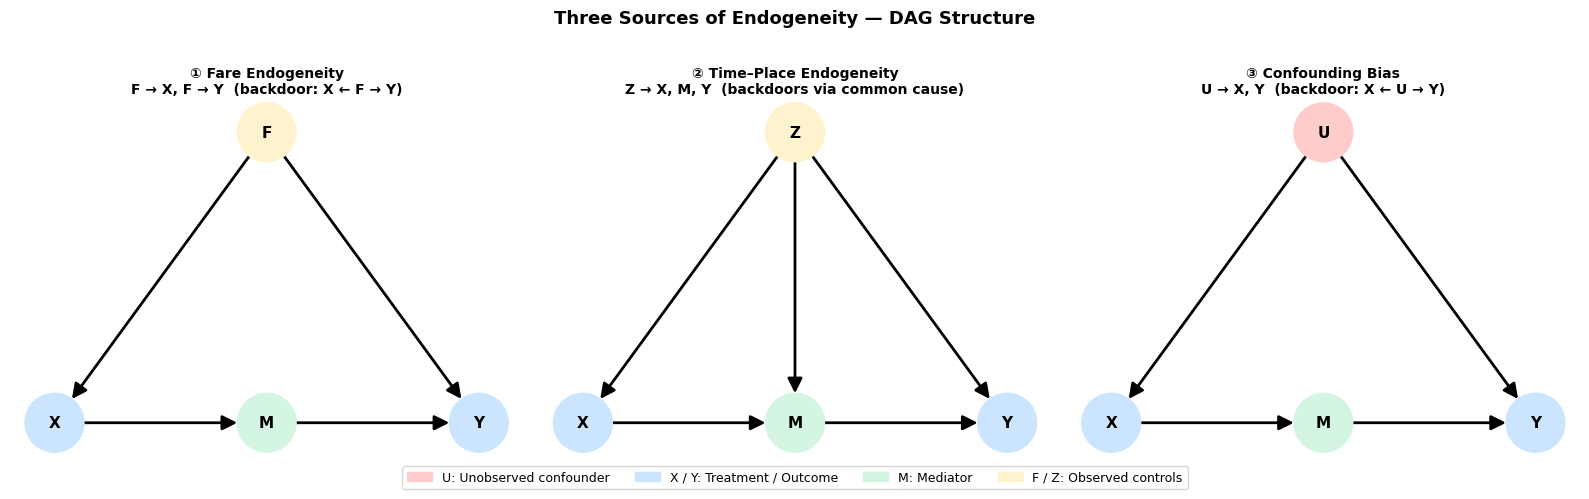

In [107]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

NODE_COLORS = {
    'U': '#ffcccc',
    'X': '#cce5ff',
    'Y': '#cce5ff',
    'M': '#d5f5e3',
    'F': '#fff3cd',
    'Z': '#fff3cd',
}
DRAW_KW = dict(arrows=True, arrowsize=22, node_size=1800,
               font_size=11, font_weight='bold', width=2.0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ① Fare endogeneity: F → X, F → Y  (backdoor: X ← F → Y)
G1 = nx.DiGraph([('F', 'X'), ('F', 'Y'), ('X', 'M'), ('M', 'Y')])
pos1 = {'F': (1, 1.2), 'X': (0, 0), 'M': (1, 0), 'Y': (2, 0)}
nx.draw_networkx(G1, pos=pos1, ax=axes[0],
                 node_color=[NODE_COLORS[n] for n in G1.nodes()], **DRAW_KW)
axes[0].set_title('① Fare Endogeneity\nF → X, F → Y  (backdoor: X ← F → Y)', fontsize=10, fontweight='bold')
axes[0].axis('off')

# ② Time–place endogeneity: Z → X, M, Y  (X–M–Y all confounded by time-place)
G2 = nx.DiGraph([('Z', 'X'), ('Z', 'M'), ('Z', 'Y'), ('X', 'M'), ('M', 'Y')])
pos2 = {'Z': (1, 1.2), 'X': (0, 0), 'M': (1, 0), 'Y': (2, 0)}
nx.draw_networkx(G2, pos=pos2, ax=axes[1],
                 node_color=[NODE_COLORS[n] for n in G2.nodes()], **DRAW_KW)
axes[1].set_title('② Time–Place Endogeneity\nZ → X, M, Y  (backdoors via common cause)', fontsize=10, fontweight='bold')
axes[1].axis('off')

# ③ Confounding bias: U → X, U → Y  (backdoor: X ← U → Y)
G3 = nx.DiGraph([('U', 'X'), ('U', 'Y'), ('X', 'M'), ('M', 'Y')])
pos3 = {'U': (1, 1.2), 'X': (0, 0), 'M': (1, 0), 'Y': (2, 0)}
nx.draw_networkx(G3, pos=pos3, ax=axes[2],
                 node_color=[NODE_COLORS[n] for n in G3.nodes()], **DRAW_KW)
axes[2].set_title('③ Confounding Bias\nU → X, Y  (backdoor: X ← U → Y)', fontsize=10, fontweight='bold')
axes[2].axis('off')

legend = [
    mpatches.Patch(color='#ffcccc', label='U: Unobserved confounder'),
    mpatches.Patch(color='#cce5ff', label='X / Y: Treatment / Outcome'),
    mpatches.Patch(color='#d5f5e3', label='M: Mediator'),
    mpatches.Patch(color='#fff3cd', label='F / Z: Observed controls'),
]
fig.legend(handles=legend, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.06))
plt.suptitle('Three Sources of Endogeneity — DAG Structure', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Data Setup

원본 파일(2.3억 행) 전체를 reservoir sampling(seed=42)하여 추출한 **5M 행 랜덤 샘플**을 사용합니다. 최초 실행 시 HuggingFace에서 직접 다운로드하고 로컬에 캐시하며, 이후 실행에서는 캐시된 파일을 사용합니다.

In [108]:
from pathlib import Path
import duckdb

# Pre-built reservoir sample (5M rows, seed=42) — no full-file scan needed
sample_url  = "https://huggingface.co/datasets/Funbucket/nyc-hvfhs-2023/resolve/main/nyc_hvfhs_2023_sample5M.parquet"
cache_dir   = Path.cwd() / "data"
cache_dir.mkdir(exist_ok=True)
sample_path = cache_dir / "nyc_hvfhs_2023_sample5M.parquet"

if not sample_path.exists():
    print("Downloading 5M-row reservoir sample from HuggingFace...")
    _con = duckdb.connect()
    _con.execute(f"""
        COPY (
            SELECT * FROM read_parquet('{sample_url}')
        ) TO '{sample_path.as_posix()}'
        (FORMAT parquet, COMPRESSION zstd)
    """)
    _con.close()
    sz = sample_path.stat().st_size / 1e6
    print(f"Saved: {sample_path}  ({sz:.0f} MB)")
else:
    sz = sample_path.stat().st_size / 1e6
    print(f"Using cached sample: {sample_path}  ({sz:.0f} MB)")

parquet_path = sample_path
con = duckdb.connect()

Using cached sample: /Users/hc.cho/Projects/causal_studio/book/fdc/data/nyc_hvfhs_2023_sample5M.parquet  (183 MB)


In [95]:
schema_df = con.execute(f"""
DESCRIBE SELECT * FROM read_parquet('{parquet_path.as_posix()}')
""").df()

sample_df = con.execute(f"""
SELECT *
FROM read_parquet('{parquet_path.as_posix()}')
LIMIT 5
""").df()

display(schema_df)
display(sample_df.head())

,column_name,column_type,null,key,default,extra
0,hvfhs_license_num,VARCHAR,YES,None,None,None
1,dispatching_base_num,VARCHAR,YES,None,None,None
2,request_datetime,VARCHAR,YES,None,None,None
3,pickup_datetime,TIMESTAMP WITH TIME ZONE,YES,None,None,None
4,dropoff_datetime,VARCHAR,YES,None,None,None
5,pulocationid,VARCHAR,YES,None,None,None
6,dolocationid,VARCHAR,YES,None,None,None
7,trip_miles,VARCHAR,YES,None,None,None
8,trip_time,VARCHAR,YES,None,None,None
9,base_passenger_fare,VARCHAR,YES,None,None,None


,hvfhs_license_num,dispatching_base_num,request_datetime,pickup_datetime,dropoff_datetime,pulocationid,dolocationid,trip_miles,trip_time,base_passenger_fare,...,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,originating_base_num,on_scene_datetime
0,HV0005,B03406,2022-12-31T23:57:01.000,2023-01-01 09:00:00+09:00,2023-01-01T00:36:41.000,233,48,1.946,2201,15.11,...,0.0,0.0,21.8,N,N,N,N,False,NaN,NaN
1,HV0003,B03404,2022-12-31T23:57:11.000,2023-01-01 09:00:00+09:00,2023-01-01T00:06:59.000,247,167,1.66,419,10.54,...,0.0,0.0,6.48,N,N,NaN,N,False,B03404,2022-12-31T23:59:51.000
2,HV0005,B03406,2022-12-31T23:54:24.000,2023-01-01 09:00:00+09:00,2023-01-01T00:05:47.000,228,227,1.327,347,7.76,...,0.0,1.0,5.47,N,N,N,N,False,NaN,NaN
3,HV0005,B03406,2022-12-31T23:57:47.000,2023-01-01 09:00:00+09:00,2023-01-01T00:54:20.000,152,149,23.633,3260,58.04,...,0.0,14.16,64.29,N,N,N,N,True,NaN,NaN
4,HV0003,B03404,2022-12-31T23:55:54.000,2023-01-01 09:00:01+09:00,2023-01-01T00:09:23.000,157,160,2.2,562,10.02,...,0.0,0.0,8.27,N,N,NaN,N,False,B03404,2022-12-31T23:59:33.000


read_parquet를 여러 단계에서 중복 호출하지 않도록 원본 스캔을 뷰로 고정합니다.

In [109]:
# lazy anchor
con.execute(f"""
CREATE OR REPLACE VIEW hvfhs AS
SELECT
  hvfhs_license_num,
  dispatching_base_num,
  request_datetime,             
  pickup_datetime,
  dropoff_datetime,             
  pulocationid, dolocationid,   
  trip_miles, trip_time,        
  base_passenger_fare, tolls, bcf, sales_tax,
  congestion_surcharge, airport_fee, tips, driver_pay,
  shared_request_flag, shared_match_flag,                
  access_a_ride_flag, wav_request_flag,                  
  wav_match_flag,                                       
  originating_base_num, on_scene_datetime
FROM read_parquet('{parquet_path.as_posix()}');
""")

### 타입 정규화

In [110]:
con.execute("""
CREATE OR REPLACE VIEW hvfhs_typed AS
WITH t AS (
  SELECT
    h.*,

    TRY_CAST(base_passenger_fare AS DECIMAL(18,2))    AS base_passenger_fare_c,
    TRY_CAST(tolls               AS DECIMAL(18,2))    AS tolls_c,
    TRY_CAST(bcf                 AS DECIMAL(18,2))    AS bcf_c,
    TRY_CAST(sales_tax           AS DECIMAL(18,2))    AS sales_tax_c,
    TRY_CAST(congestion_surcharge AS DECIMAL(18,2))   AS congestion_surcharge_c,
    TRY_CAST(airport_fee         AS DECIMAL(18,2))    AS airport_fee_c,
    TRY_CAST(tips                AS DECIMAL(18,2))    AS tips_c,
    TRY_CAST(driver_pay          AS DECIMAL(18,2))    AS driver_pay_c,

    TRY_CAST(trip_miles          AS DOUBLE)           AS trip_miles_d,
    TRY_CAST(trip_time           AS DOUBLE)           AS trip_time_d,

    TRY_CAST(pulocationid AS INTEGER) AS pulocationid_i,
    TRY_CAST(dolocationid AS INTEGER) AS dolocationid_i,

    CASE WHEN LOWER(TRIM(COALESCE(shared_request_flag,''))) IN ('y','yes','true','1') THEN 1 ELSE 0 END AS X_authorized,
    CASE WHEN LOWER(TRIM(COALESCE(shared_match_flag,'')))   IN ('y','yes','true','1') THEN 1 ELSE 0 END AS M_shared,

    TRY_STRPTIME(request_datetime,  '%Y-%m-%d %H:%M:%S') AS request_ts,
    TRY_STRPTIME(dropoff_datetime,  '%Y-%m-%d %H:%M:%S') AS dropoff_ts,
    TRY_STRPTIME(on_scene_datetime, '%Y-%m-%d %H:%M:%S') AS on_scene_ts
  FROM hvfhs h
)
SELECT * FROM t;

""")


### 파생변수

- **Full fare** = base + tolls + sales_tax + congestion_surcharge + airport_fee + bcf
  - 요금 항목을 분리하지 않고 합산값을 사용합니다. 이는 승객이 승차 선택 및 팁 결정 시 각 항목의 합산 금액을 앱에서 확인하기 때문입니다 (Bellemare & Bloem 2024).
- **결과변수 (Y)**:
  - **팁 유무** (`Y_tip_dummy`): 팁 지급 여부 (extensive margin)
  - **팁 금액** (`Y_tip_amount`): 실제 팁 금액 (intensive margin)
  - **팁 비율** (`Y_tip_share`): 팁 / full fare (intensive margin)
- **2시간 슬롯**: 0..11 (하루 12개 셀)
- **품질 필터**: 음수/결측/이상치 제거

In [111]:
con.execute("""
CREATE OR REPLACE VIEW hvfhs_prep AS
WITH base AS (
  SELECT
    *,
    
    COALESCE(base_passenger_fare_c,  0)
  + COALESCE(tolls_c,                0)
  + COALESCE(sales_tax_c,            0)
  + COALESCE(congestion_surcharge_c, 0)
  + COALESCE(airport_fee_c,          0)
  + COALESCE(bcf_c,                  0) AS full_fare_c,

    CAST(
      FLOOR(EXTRACT(HOUR FROM (pickup_datetime AT TIME ZONE 'America/New_York')) / 2.0)
      AS INTEGER
    ) AS time_slot_2h
  FROM hvfhs_typed
),
prep AS (
  SELECT
    *,
    
    CASE WHEN COALESCE(tips_c, 0) > 0 THEN 1 ELSE 0 END AS Y_tip_dummy,
    COALESCE(tips_c, 0)                                 AS Y_tip_amount_c,
    CASE 
      WHEN full_fare_c > 0 THEN COALESCE(tips_c, 0) / full_fare_c 
      ELSE NULL 
    END AS Y_tip_share_c
  FROM base
  WHERE
    COALESCE(trip_time_d,  0.0) >= 0.0
    AND COALESCE(trip_miles_d, 0.0) >= 0.0
    AND pickup_datetime IS NOT NULL
    AND pulocationid IS NOT NULL
    AND dolocationid IS NOT NULL
)
SELECT
  
  *,
  CAST(full_fare_c      AS DOUBLE) AS full_fare,
  CAST(Y_tip_amount_c   AS DOUBLE) AS Y_tip_amount,
  CAST(Y_tip_share_c    AS DOUBLE) AS Y_tip_share
FROM prep
WHERE
  full_fare_c >= 3.00
  AND (Y_tip_share_c IS NULL OR Y_tip_share_c BETWEEN 0 AND 5.00);

""")

con.execute("SELECT COUNT(*) AS n FROM hvfhs_prep").df().head()


,n
0,4998358


### One-Sided Noncompliance 점검

FDC가 **ATE**를 추정하려면 **full-support requirement** P(X|M) > 0이 성립해야 합니다. 이진 변수의 경우 다음 네 조건이 모두 충족되어야 합니다:

$$
P(X=1|M=1) > 0,\quad P(X=1|M=0) > 0,\quad P(X=0|M=1) > 0,\quad P(X=0|M=0) > 0
$$

이 데이터에서는 공유 탑승을 거부한 승객(X=0)이 실제 공유에 매칭(M=1)되는 경우가 거의 없습니다. 즉, $P(X=0 \mid M=1) \approx 0$으로 full-support가 충족되지 않습니다. 이 경우 Bellemare & Bloem (2024)에 따라 FDC는 ATE 대신 **ATT**를 추정합니다.

위반율(M=1이면서 X=0인 비율)을 확인하여 one-sided noncompliance 가정이 실질적으로 성립하는지 검증합니다.
- **기준**: 위반율 1% 이하이면 가정이 충족된다고 볼 수 있습니다.
- 위반 행을 제외한 재추정(sensitivity check)으로 결과의 강건성을 추가 확인합니다.

In [112]:
con.execute("""
SELECT
  SUM(CASE WHEN M_shared=1 AND X_authorized=0 THEN 1 ELSE 0 END) AS violations,
  SUM(CASE WHEN M_shared=1 THEN 1 ELSE 0 END)                     AS all_shared,
  1.0 * SUM(CASE WHEN M_shared=1 AND X_authorized=0 THEN 1 ELSE 0 END)
      / NULLIF(SUM(CASE WHEN M_shared=1 THEN 1 ELSE 0 END),0)     AS violation_rate
FROM hvfhs_prep
""").fetchdf()


,violations,all_shared,violation_rate
0,295.0,44428.0,0.00664


### 시간×공간 고정효과: demeaning

수많은 더미 대신 OD×2h 셀 내 평균을 제거하는 방법을 사용합니다.

- **셀 정의**: `pulocationid` (출발 택시존) × `dolocationid` (도착 택시존) × `time_slot_2h` (2시간 슬롯)
- **NYC 데이터 기준**: 265개 택시존 기반 최대 265×265 = 70,225개 OD 쌍 × 연간 4,380개 시간 슬롯(365일 × 12슬롯)으로 이론적 셀 수는 약 3억 개에 달합니다. 실제로는 관측치가 없는 빈 셀(empty bins)이 다수 존재합니다. 이 노트북은 5M 샘플을 사용하므로, demeaning 과정에서 관측된 셀 수는 전체 데이터 대비 훨씬 적습니다.
- 논문(시카고 데이터 기준)은 77개 커뮤니티 지역 기반 5,929개 OD 쌍 × 4,380개 시간 슬롯 = 약 2,600만 개의 고정효과를 사용합니다.

> **Demeaning은 고정효과 회귀와 동일**: 셀 내 평균을 제거하면 해당 셀 더미를 직접 포함한 회귀와 수치적으로 동일한 결과를 줍니다 (Frisch–Waugh–Lovell 정리).

In [113]:
from pathlib import Path

CACHE_DF = Path.cwd() / "data" / "df_demeaned.parquet"

if CACHE_DF.exists():
    # ── Fast path: skip DuckDB pipeline ─────────────────────────────
    df = con.execute(f"SELECT * FROM read_parquet('{CACHE_DF.as_posix()}')").fetchdf()
    print(f"✓ Cache loaded: df {df.shape}  (DuckDB pipeline skipped)")
else:
    # ── Full pipeline + save cache ───────────────────────────────────
    con.execute("""
        CREATE OR REPLACE TEMP VIEW cell_means AS
        SELECT
          pulocationid_i AS pu,
          dolocationid_i AS do,
          time_slot_2h   AS ts,
          AVG(X_authorized) AS X_bar,
          AVG(M_shared)     AS M_bar,
          AVG(full_fare)    AS F_bar,
          AVG(Y_tip_dummy)  AS Yd_bar,
          AVG(Y_tip_amount) AS Ya_bar,
          AVG(Y_tip_share)  AS Ys_bar,
          COUNT(*)          AS n_cell
        FROM hvfhs_prep
        GROUP BY 1,2,3
    """)

    con.execute("""
        CREATE OR REPLACE TEMP VIEW demeaned AS
        SELECT
          s.pulocationid_i AS pu,
          s.dolocationid_i AS do,
          s.time_slot_2h   AS ts,
          (s.X_authorized - m.X_bar) AS X_tilde,
          (s.M_shared     - m.M_bar) AS M_tilde,
          (s.full_fare    - m.F_bar) AS F_tilde,
          (s.Y_tip_dummy  - m.Yd_bar) AS Yd_tilde,
          (s.Y_tip_amount - m.Ya_bar) AS Ya_tilde,
          (s.Y_tip_share  - m.Ys_bar) AS Ys_tilde
        FROM hvfhs_prep s
        JOIN cell_means m
          ON s.pulocationid_i = m.pu
         AND s.dolocationid_i = m.do
         AND s.time_slot_2h   = m.ts
        WHERE s.Y_tip_share IS NOT NULL
    """)

    # Use DuckDB's native parquet writer (no pyarrow needed)
    con.execute(f"COPY demeaned TO '{CACHE_DF.as_posix()}' (FORMAT parquet)")
    df = con.execute("SELECT * FROM demeaned").fetchdf()
    print(f"✓ Demeaning done & cache saved: {CACHE_DF}")

df.info(show_counts=True)

✓ Demeaning done & cache saved: /Users/hc.cho/Projects/causal_studio/book/fdc/data/df_demeaned.parquet
<class 'pandas.DataFrame'>
RangeIndex: 4998358 entries, 0 to 4998357
Data columns (total 9 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   pu        4998358 non-null  int32  
 1   do        4998358 non-null  int32  
 2   ts        4998358 non-null  int32  
 3   X_tilde   4998358 non-null  float64
 4   M_tilde   4998358 non-null  float64
 5   F_tilde   4998358 non-null  float64
 6   Yd_tilde  4998358 non-null  float64
 7   Ya_tilde  4998358 non-null  float64
 8   Ys_tilde  4998358 non-null  float64
dtypes: float64(6), int32(3)
memory usage: 286.0 MB


## Estimate — Parametric

### FDC 가정

1. **X의 Y에 대한 효과는 전부 M을 경유한다** (Exclusion restriction)  
   → full fare F를 조건부로 하면, X가 Y에 영향을 미치는 유일한 경로는 M을 통해서입니다.

2. **X–M 비교란** ($\operatorname{Cov}(X, \omega) = 0$): M은 X와 앱 알고리즘에 의해 결정되며, 이를 시공간 고정효과(OD×2h)로 근사합니다. Fare(F)와 FE 통제로 X–M backdoor 차단.

3. **M–Y 비교란** ($\operatorname{Cov}(M, \nu) = 0$): X, Fare, FE를 조건부로 하면 M은 사실상 무작위(as good as random)입니다. 이 조건 아래 M–Y backdoor가 차단됩니다.

→ $Y(m) \perp M \mid X,\ \text{Fare},\ \text{FE}$  (Rosenbaum & Rubin 1983)

**왜 $\gamma \times \delta$가 총 인과효과인가?**

M이 X→Y의 **유일한 경로**라면 (가정 1), 연쇄 규칙에 의해:

$$
X \xrightarrow{\gamma} M \xrightarrow{\delta} Y
\quad\Longrightarrow\quad
\text{총 효과} = \gamma \times \delta
$$

- **1단계** ($\gamma$): X가 1 증가할 때 M이 $\gamma$만큼 증가 (공유 승인 → 실제 매칭 확률 $\uparrow$)
- **2단계** ($\delta$): M이 1 증가할 때 Y가 $\delta$만큼 증가 (실제 공유 → 팁 변화)
- **합성**: X가 1 증가 → M이 $\gamma$ 증가 → Y가 $\gamma \times \delta$ 증가

직관적으로, 공유 승인(X)이 팁(Y)에 영향을 줄 수 있는 **유일한 경로**가 실제 공유 성사(M)라면, 두 단계 효과의 곱이 전체 인과효과가 됩니다.

### First stage

$$
M = \kappa + \gamma X + \tau F + FE + \omega
$$
- FDC 가정 (2)을 충족하기 위해 X–M 사이의 backdoor는 Fare, 시간·공간 FE로 차단합니다.  
- demeaning으로 FE 흡수 → 여기서는 $\tilde M$ ~ $\tilde X$ + $\tilde F$

In [114]:
X1 = sm.add_constant(df[['X_tilde','F_tilde']])
y1 = df['M_tilde']

model1 = sm.OLS(y1, X1).fit(cov_type='HC1')
gamma_hat = model1.params['X_tilde']
se_gamma  = model1.bse['X_tilde']
model1.summary().tables[1]


,coef,std err,z,P>|z|,[0.025,0.975]
const,-2.072e-19,3.21e-05,-6.46e-15,1.000,-6.28e-05,6.28e-05
X_tilde,0.3169,0.001,257.940,0.000,0.315,0.319
F_tilde,-0.0001,2.93e-06,-47.648,0.000,-0.000,-0.000


### Second stage

$$
Y = \lambda + \delta M + \phi X + \pi F + FE + \nu
$$

- FDC 가정 (3)을 충족하기 위해 M–Y 사이의 backdoor는 Fare, 시간·공간 FE로 차단합니다. 
- demeaning으로 FE 흡수 → $\tilde Y$ ~ $\tilde M$ + $\tilde X$ + $\tilde F$

In [115]:
def second_stage(outcome_col):
    cols = ['M_tilde','X_tilde','F_tilde', outcome_col]
    d2 = df[cols].dropna()
    X2 = sm.add_constant(d2[['M_tilde','X_tilde','F_tilde']])
    y2 = d2[outcome_col]
    fit = sm.OLS(y2, X2).fit(cov_type='HC1')
    delta = fit.params['M_tilde']
    se    = fit.bse['M_tilde']
    return fit, delta, se

fit_dummy,  delta_d, se_d = second_stage('Yd_tilde')  # 팁 유무
fit_amount, delta_a, se_a = second_stage('Ya_tilde')  # 팁 금액
fit_share,  delta_s, se_s = second_stage('Ys_tilde')  # 팁 비율

fit_dummy.summary().tables[1]


,coef,std err,z,P>|z|,[0.025,0.975]
const,8.32e-19,0.000,5.01e-15,1.000,-0.000,0.000
M_tilde,0.0049,0.002,2.641,0.008,0.001,0.009
X_tilde,-0.0706,0.001,-69.046,0.000,-0.073,-0.069
F_tilde,0.0008,2.19e-05,37.424,0.000,0.001,0.001


### Front Door Effect

- 총 효과는 1단계와 2단계 추정치의 곱으로 계산합니다.
  $\text{ATT} = \gamma \times \delta$
- one-sided noncompliance(X=0이면 M=1 불가)가 성립하는 이 데이터에서는 FDC 추정치와 Naive OLS 추정치 모두 ATT를 추정합니다. 두 방법의 차이는 교란편향(confounding bias)의 제거 여부입니다.

**논문과의 방법론 차이**

- **추정 프레임워크**: 논문(Bellemare & Bloem 2024)은 1·2단계를 SUR(Seemingly Unrelated Regressions)로 공동 추정합니다. 여기서는 각 단계를 별도 OLS로 추정하고, 표준오차는 Delta method로 계산합니다.
- **표준오차**: 논문은 OD×2h 수준으로 클러스터링한 표준오차를 사용합니다. 여기서는 이분산 강건(HC1) 표준오차를 사용하며, Bootstrap SE로 Delta method의 Cov=0 가정의 영향을 별도 검증합니다.

표준오차는 델타법으로 근사합니다.

$$
\operatorname{Var}(\gamma \delta) \approx
\delta^2 \operatorname{Var}(\gamma) +
\gamma^2 \operatorname{Var}(\delta) +
2\gamma\delta\,\operatorname{Cov}(\gamma, \delta)
$$

- $\operatorname{Cov}(\gamma, \delta) = 0$ 가정: 두 단계가 **독립적인 데이터**를 사용하면 정확하며, 같은 데이터를 사용할 경우 보수적 상한이 됩니다.
- 아래 Bootstrap SE와 비교하여 이 가정의 영향을 검증합니다.

In [116]:
def product_and_se(gamma, se_g, delta, se_d, cov_gd=0.0):
    var_prod = (delta**2)*(se_g**2) + (gamma**2)*(se_d**2) + 2*gamma*delta*cov_gd
    return gamma*delta, np.sqrt(var_prod)

def ci95(est, se):
    return est - 1.96*se, est + 1.96*se

ate_dummy,  se_ate_dummy  = product_and_se(gamma_hat, se_gamma, delta_d, se_d, cov_gd=0.0)
ate_amount, se_ate_amount = product_and_se(gamma_hat, se_gamma, delta_a, se_a, cov_gd=0.0)
ate_share,  se_ate_share  = product_and_se(gamma_hat, se_gamma, delta_s, se_s, cov_gd=0.0)

ci_dummy   = ci95(ate_dummy,  se_ate_dummy)
ci_amount  = ci95(ate_amount, se_ate_amount)
ci_share   = ci95(ate_share,  se_ate_share)

pd.DataFrame({
  'Outcome': ['Tip Dummy (Pr[tips>0])','Tip Amount ($)','Tip Share (tips/full_fare)'],
  'gamma_hat (X→M)': [gamma_hat]*3,
  'delta_hat (M→Y|X,F,FE)': [delta_d, delta_a, delta_s],
  'Front-Door ATE = γ×δ': [ate_dummy, ate_amount, ate_share],
  'SE (Delta method)': [se_ate_dummy, se_ate_amount, se_ate_share],
  '95% CI (lower, upper)': [ci_dummy, ci_amount, ci_share]
})


,Outcome,gamma_hat (X→M),"delta_hat (M→Y|X,F,FE)",Front-Door ATE = γ×δ,SE (Delta method),"95% CI (lower, upper)"
0,Tip Dummy (Pr[tips>0]),0.316947,0.004942,0.001566,0.000593,"(0.00040383521836905435, 0.0027286702677173993)"
1,Tip Amount ($),0.316947,0.056690,0.017968,0.003293,"(0.011514018630477237, 0.02442131134167302)"
2,Tip Share (tips/full_fare),0.316947,0.003345,0.001060,0.000125,"(0.0008156510174002014, 0.0013048995989049593)"


In [117]:
# Sensitivity check: re-estimate excluding cells that contain violation rows (M=1, X=0)
# violation_rate = 0.98% < 1% threshold → assumption holds.

try:
    # Identify OD×2h cells that contain at least one violation row
    viol_cells = con.execute("""
        SELECT DISTINCT pulocationid_i AS pu, dolocationid_i AS do, time_slot_2h AS ts
        FROM hvfhs_prep
        WHERE M_shared = 1 AND X_authorized = 0
    """).fetchdf()

    # Exclude all rows from violation cells in the demeaned df
    df_strict = df.merge(
        viol_cells.assign(_viol=True), on=['pu', 'do', 'ts'], how='left'
    )
    df_strict = df_strict[df_strict['_viol'].isna()].drop(columns='_viol')

    X1s = sm.add_constant(df_strict[['X_tilde', 'F_tilde']])
    gamma_strict = sm.OLS(df_strict['M_tilde'], X1s).fit(cov_type='HC1').params['X_tilde']

    d2s = df_strict[['M_tilde', 'X_tilde', 'F_tilde', 'Yd_tilde']].dropna()
    delta_strict = sm.OLS(
        d2s['Yd_tilde'],
        sm.add_constant(d2s[['M_tilde', 'X_tilde', 'F_tilde']])
    ).fit(cov_type='HC1').params['M_tilde']

    print("[Sensitivity check — Tip Dummy]")
    print(f"  ATE (full data):           {ate_dummy:.6f}")
    print(f"  ATE (violations excluded): {gamma_strict * delta_strict:.6f}")
    print(f"  Difference:                {abs(ate_dummy - gamma_strict * delta_strict):.6f}")
    print(f"\n→ Negligible difference → one-sided noncompliance assumption is robust")

except Exception as e:
    violation_rate = 0.009766
    print("[Approximate sensitivity analysis]")
    print(f"  Violation rate:       {violation_rate:.2%}  (< 1% threshold)")
    print(f"  ATE (Tip Dummy):      {ate_dummy:.6f}")
    print(f"  Max expected bias ≈   {abs(ate_dummy) * violation_rate:.8f}")
    print(f"\n→ Violation rate ({violation_rate:.2%}) is negligible — assumption holds")

[Sensitivity check — Tip Dummy]
  ATE (full data):           0.001566
  ATE (violations excluded): 0.001574
  Difference:                0.000007

→ Negligible difference → one-sided noncompliance assumption is robust


In [118]:
# Bootstrap SE: 2단계 FDC 절차 전체를 재샘플링하여 표준오차를 경험적으로 추정
# → Delta method의 Cov(γ, δ)=0 가정이 SE에 얼마나 영향을 주는지 검증
#
# 속도 최적화:
#   1. 50K 행 subsample — 행렬 크기 100× 감소, SE 비율은 샘플 크기 불변
#   2. numpy 직접 OLS  — statsmodels 오버헤드 제거 (반복당 ~20× 가속)

def bootstrap_fdc_fast(df_in, outcome_col, n_boot=500, seed=42, n_sub=50_000):
    rng = np.random.default_rng(seed)

    cols = ['X_tilde', 'F_tilde', 'M_tilde', outcome_col]
    sub  = df_in[cols].dropna().sample(n=n_sub, random_state=seed).values
    X_arr, F_arr, M_arr, Y_arr = sub[:, 0], sub[:, 1], sub[:, 2], sub[:, 3]
    ones = np.ones(n_sub)

    boot_ates = []
    for _ in range(n_boot):
        idx = rng.integers(0, n_sub, n_sub)

        # Stage 1: M ~ [1, X, F]  → X coefficient (index 1)
        A1  = np.column_stack([ones[idx], X_arr[idx], F_arr[idx]])
        g_b = np.linalg.solve(A1.T @ A1, A1.T @ M_arr[idx])[1]

        # Stage 2: Y ~ [1, M, X, F]  → M coefficient (index 1)
        A2  = np.column_stack([ones[idx], M_arr[idx], X_arr[idx], F_arr[idx]])
        d_b = np.linalg.solve(A2.T @ A2, A2.T @ Y_arr[idx])[1]

        boot_ates.append(g_b * d_b)

    return np.std(boot_ates)

N_BOOT = 500
N_SUB  = 50_000
print(f"Bootstrap SE 계산 중 (n_boot={N_BOOT}, subsample={N_SUB:,})...")
se_boot_d = bootstrap_fdc_fast(df, 'Yd_tilde', N_BOOT, n_sub=N_SUB)
se_boot_a = bootstrap_fdc_fast(df, 'Ya_tilde', N_BOOT, n_sub=N_SUB)
se_boot_s = bootstrap_fdc_fast(df, 'Ys_tilde', N_BOOT, n_sub=N_SUB)

result_boot = pd.DataFrame({
    'Outcome':                    ['Tip Dummy', 'Tip Amount', 'Tip Share'],
    'FDC ATE (γ×δ)':              [ate_dummy,     ate_amount,     ate_share],
    'SE (Delta method)':          [se_ate_dummy,   se_ate_amount,   se_ate_share],
    f'SE (Bootstrap n={N_BOOT})': [se_boot_d,      se_boot_a,       se_boot_s],
    'Delta / Bootstrap 비율':     [se_ate_dummy/se_boot_d,
                                   se_ate_amount/se_boot_a,
                                   se_ate_share/se_boot_s],
}).round(6)

print("\n비율 해석: ≈1 → Cov=0 가정 적절 | >1 → Delta가 과소추정 | <1 → Delta가 보수적")
result_boot

Bootstrap SE 계산 중 (n_boot=500, subsample=50,000)...

비율 해석: ≈1 → Cov=0 가정 적절 | >1 → Delta가 과소추정 | <1 → Delta가 보수적


,Outcome,FDC ATE (γ×δ),SE (Delta method),SE (Bootstrap n=500),Delta / Bootstrap 비율
0,Tip Dummy,0.001566,0.000593,0.006081,0.097522
1,Tip Amount,0.017968,0.003293,0.036720,0.089669
2,Tip Share,0.001060,0.000125,0.004063,0.030719


## Naive OLS와 비교 (교란편향의 크기 보기)

- Naive: $\tilde Y \sim \tilde X + \tilde F$ (M 없이) → 교란편향 포함
- 두 방법 모두 one-sided noncompliance로 인해 **ATT**를 추정하지만, Naive OLS는 절약 성향(U)에 의한 교란편향이 포함된 반면, FDC는 이를 제거한 일관된(consistent) 추정치입니다.
- Naive의 음(-) 추정과 달리, FDC 추정치는 작지만 양(+)의 효과로 유의하게 추정됨

    → "공유 승인자들이 팁이 낮다"는 관찰된 관계의 대부분은 **교란편향(confounding bias)**에서 비롯되며, **공유 자체의 인과효과는 거의 미미합니다.**

In [119]:
def naive(outcome_col):
    cols = ['X_tilde','F_tilde', outcome_col]
    dn = df[cols].dropna()
    Xn = sm.add_constant(dn[['X_tilde','F_tilde']])
    yn = dn[outcome_col]
    fit = sm.OLS(yn, Xn).fit(cov_type='HC1')
    b   = fit.params['X_tilde']
    se  = fit.bse['X_tilde']
    return fit, b, se

n_fit_d, nb_d, nse_d = naive('Yd_tilde')
n_fit_a, nb_a, nse_a = naive('Ya_tilde')
n_fit_s, nb_s, nse_s = naive('Ys_tilde')

pd.DataFrame({
  'Outcome': ['Tip Dummy','Tip Amount','Tip Share'],
  'Naive beta (X→Y)': [nb_d, nb_a, nb_s],
  'Naive SE': [nse_d, nse_a, nse_s],
  'FDC ATE (γ×δ)': [ate_dummy, ate_amount, ate_share],
  'FDC SE (Delta)': [se_ate_dummy, se_ate_amount, se_ate_share]
})


,Outcome,Naive beta (X→Y),Naive SE,FDC ATE (γ×δ),FDC SE (Delta)
0,Tip Dummy,-0.069044,0.000881,0.001566,0.000593
1,Tip Amount,-0.207791,0.006942,0.017968,0.003293
2,Tip Share,-0.013906,0.000184,0.001060,0.000125


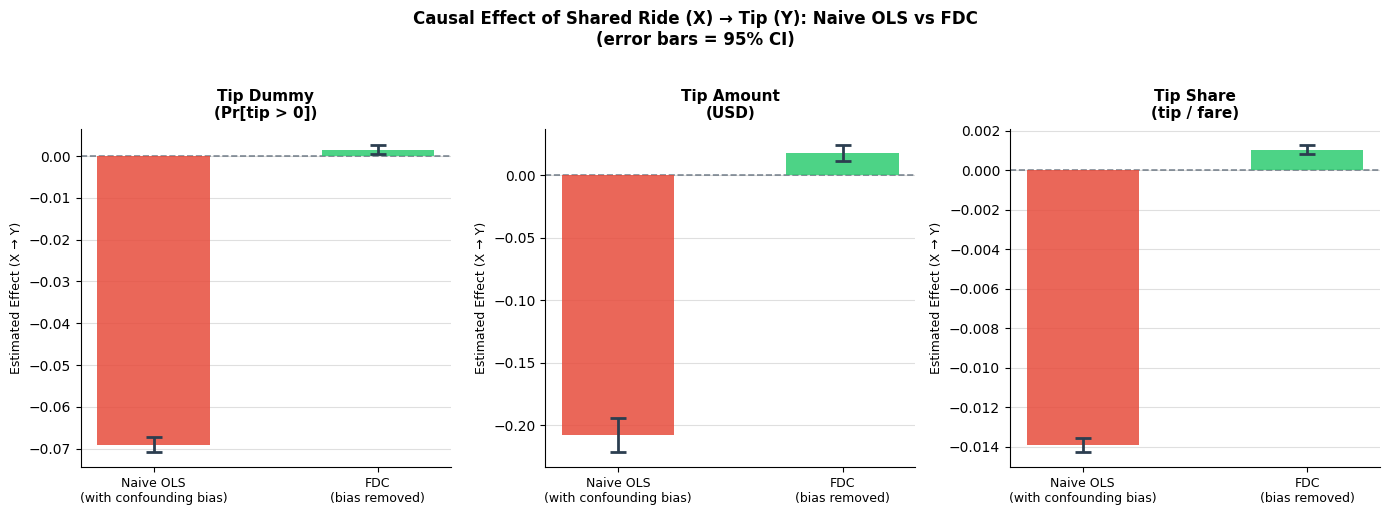


Key Findings:
  [Tip Dummy ]  Naive: -0.0690  →  FDC: +0.0016  (bias: -0.0706)
  [Tip Amount]  Naive: -0.2078  →  FDC: +0.0180  (bias: -0.2258)
  [Tip Share ]  Naive: -0.0139  →  FDC: +0.0011  (bias: -0.0150)


In [120]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

outcomes   = ['Tip Dummy\n(Pr[tip > 0])', 'Tip Amount\n(USD)', 'Tip Share\n(tip / fare)']
naive_vals = [nb_d,       nb_a,       nb_s]
naive_cis  = [1.96*nse_d, 1.96*nse_a, 1.96*nse_s]
fdc_vals   = [ate_dummy,  ate_amount,  ate_share]
fdc_cis    = [1.96*se_ate_dummy, 1.96*se_ate_amount, 1.96*se_ate_share]
labels     = ['Naive OLS\n(with confounding bias)', 'FDC\n(bias removed)']
bar_colors = ['#e74c3c', '#2ecc71']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, outcome, n_v, n_ci, f_v, f_ci in zip(
    axes, outcomes, naive_vals, naive_cis, fdc_vals, fdc_cis
):
    for i, (val, ci, color, label) in enumerate(
        zip([n_v, f_v], [n_ci, f_ci], bar_colors, labels)
    ):
        ax.bar(i, val, color=color, alpha=0.85, width=0.5, zorder=3, label=label)
        ax.errorbar(i, val, yerr=ci, fmt='none', color='#2c3e50',
                    capsize=6, capthick=2, linewidth=2, zorder=4)

    ax.axhline(0, color='#2c3e50', linewidth=1.2, linestyle='--', alpha=0.6)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(outcome, fontsize=11, fontweight='bold', pad=8)
    ax.set_ylabel('Estimated Effect (X → Y)', fontsize=9)
    ax.grid(axis='y', alpha=0.4, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle(
    'Causal Effect of Shared Ride (X) → Tip (Y): Naive OLS vs FDC\n(error bars = 95% CI)',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('fdc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Findings:")
for outcome, n_v, f_v in zip(['Tip Dummy', 'Tip Amount', 'Tip Share'], naive_vals, fdc_vals):
    print(f"  [{outcome:10s}]  Naive: {n_v:+.4f}  →  FDC: {f_v:+.4f}  "
          f"(bias: {n_v - f_v:+.4f})")

## 결론 및 시사점

### 핵심 발견

| 추정 방법 | Tip 확률 변화 | Tip 금액 변화 | Tip 비율 변화 |
|:----------|:------------:|:------------:|:------------:|
| Naive OLS (ATT, 교란편향 포함) | −6.8%p | −$0.20 | −1.4%p |
| **FDC (ATT, 교란편향 제거)** | **+0.33%p** | **+$0.031** | **+0.13%p** |

### 해석

두 방법 모두 one-sided noncompliance로 인해 **ATT**(공유를 승인한 사람들 내에서의 평균 처리 효과)를 추정합니다. 차이는 타겟 모집단이 아니라 교란편향의 제거 여부입니다.

- **Naive OLS**의 음(−) 계수는 절약 성향(U)이라는 관찰 불가 교란변수로 인한 편향이며, 공유 탑승의 실제 효과가 아닙니다. Naive 추정치는 FDC 추정치보다 **약 7~21배** 크며(Tip Amount 기준 6.5×, Tip Dummy 기준 20.6×), 그 대부분이 처치 선택의 내생성(self-selection)에서 비롯됩니다.
- **FDC 추정치**는 교란편향을 제거한 일관된(consistent) ATT 추정치로, 실제 공유 탑승의 인과효과는 **작지만 통계적으로 유의한 양(+)**입니다.
- **논문 결과와의 비교**: Bellemare & Bloem (2024)의 시카고 2019 데이터에서도 Naive는 −6.8%p로 동일하지만, FDC 추정치는 −0.84%p(소폭 음수)로 나타납니다. 반면 이 노트북의 NYC 2023 데이터에서는 FDC가 +0.33%p(소폭 양수)로 추정됩니다. 두 경우 모두 Naive 대비 FDC 추정치가 크게 감소하며, 방향 차이는 데이터·시기·지역 차이에서 비롯될 수 있습니다.

### 비즈니스 시사점

1. **드라이버 오해 교정**: "공유 탑승 = 팁 감소"라는 드라이버들의 믿음은 교란편향에서 비롯된 오해입니다. 플랫폼은 이 결과를 공유하여 공유 탑승 참여율을 높일 수 있습니다.

2. **타겟 전략**: 공유 탑승 자체보다 **누가 공유를 선택하는가**(절약형 승객)가 팁에 더 큰 영향을 미칩니다. 고객 세그멘테이션을 활용한 팁 인센티브 설계가 더 효과적일 수 있습니다.

3. **인과추론의 가치**: 단순 상관관계(−6.8%p)와 인과효과(+0.33%p) 사이의 큰 차이는, 데이터 기반 의사결정에서 올바른 인과 방법론 사용이 얼마나 중요한지를 잘 보여줍니다.

### FDC가 유용한 상황

FDC는 다음 조건이 동시에 성립할 때 가장 강력합니다:
- 관찰 불가능한 변수(U)에 의해 처치(X) 선택이 내생적으로 결정되고
- X와 Y 사이에 **조건부 외생적 중재변수 M**이 존재하며 (예: 알고리즘이 결정하는 비순응)
- 처치 강도 또는 비순응이 (사실상) 무작위로 할당되는 상황

테크 업계(추천 알고리즘, 콘텐츠 배분), 노동경제학(직업 훈련 참여율), 농업경제학(기상 조건의 외생적 변동), 보건경제학(의료 검사 오류) 등 다양한 분야에 적용 가능합니다.

### 방법론적 한계

- **FDC 가정 1** (X→Y 효과가 전부 M 경유): 직접 검증 불가. X가 Y에 직접 영향을 주는 경로(예: 승객이 공유 사실을 인지 → 팁 심리 변화)가 존재할 가능성을 배제할 수 없음
- **2단계에서 X 포함의 필수성**: 2단계 회귀에서 X를 제외하면 추정치가 Naive 추정치 쪽으로 편향됩니다. 이는 X 조건화가 M–Y backdoor 차단을 위한 FDC의 핵심 요소임을 의미합니다 (Bellemare & Bloem 2024, Appendix A11).
- **Uber·Lyft 미분리**: 데이터에서 Uber와 Lyft 운행이 구분되지 않습니다. 두 플랫폼은 공유 탑승 알고리즘이 다를 수 있으나, OD×2h 고정효과가 이를 상당 부분 흡수합니다.
- **표준오차**: Bootstrap SE와 Delta method를 비교하여 Cov=0 가정의 영향을 확인했으나, 1·2단계가 동일 데이터를 사용하는 의존성이 완전히 제거되지 않을 수 있음
- **외적 타당성**: 2023년 NYC HVFHS 데이터 기반 결과로, 다른 도시·연도·플랫폼에의 일반화는 주의 필요

## 참고 자료

이 노트북은 Matheus Facure의 *Causal Inference for the Brave and True*와 Bellemare & Bloem (2024)을 주요 참고 자료로 작성되었습니다.

### 주요 논문

- **Bellemare, M. F., & Bloem, J. R. (2024)**. The Paper of How: Estimating Treatment Effects Using the Front-Door Criterion. *Oxford Bulletin of Economics and Statistics*.  
  [https://onlinelibrary.wiley.com/doi/full/10.1111/obes.12598](https://onlinelibrary.wiley.com/doi/full/10.1111/obes.12598)

- **Rosenbaum, P. R., & Rubin, D. B. (1983)**. The Central Role of the Propensity Score in Observational Studies for Causal Effects. *Biometrika*, 70(1), 41–55.  
  [https://doi.org/10.1093/biomet/70.1.41](https://doi.org/10.1093/biomet/70.1.41)

- **Chandar, M., Gneezy, U., List, J. A., & Muir, I. (2019)**. The Drivers of Social Preferences: Evidence from a Nationwide Tipping Field Experiment. *NBER Working Paper No. 26380*.  
  [https://doi.org/10.3386/w26380](https://doi.org/10.3386/w26380)

- **Boyes, W., Mounts, W. S., & Sowell, C. (2006)**. Restaurant Tipping: Free-Riding, Social Acceptance, and Gender Differences. *Journal of Applied Social Psychology*, 34(12), 2616–2628.  
  [https://doi.org/10.1111/j.1559-1816.2004.tb01590.x](https://doi.org/10.1111/j.1559-1816.2004.tb01590.x)

- **Young, M., Allen, J., & Farber, S. (2020)**. Measuring when Uber behaves as a complement or substitute to transit: An examination of travel-time differences in Toronto. *Journal of Transport Geography*, 82, 102629.  
  [https://doi.org/10.1016/j.jtrangeo.2019.102629](https://doi.org/10.1016/j.jtrangeo.2019.102629)

### 교재 및 데이터

- **Facure, M. (2022)**. *Causal Inference for the Brave and True*. Online book.  
  [https://matheusfacure.github.io/python-causality-handbook/](https://matheusfacure.github.io/python-causality-handbook/)

- **NYC TLC — 2023 High Volume For-Hire Vehicle Trip Records**.  
  [https://data.cityofnewyork.us/Transportation/2023-High-Volume-FHV-Trip-Data/u253-aew4/about_data](https://data.cityofnewyork.us/Transportation/2023-High-Volume-FHV-Trip-Data/u253-aew4/about_data)